# 부스팅(Boosting)
- 기본적으로는 랜덤 포래스트와 유사한다.
- 다른 점은 각 트리들이 던지는 답의 오차들을 보정할 수 있도록 오차 함수가 존재한다.
- 이를 통해 성능을 끌어 올린다.
- 너어어어어어어어어어어어어어어무 오래걸려요.ㅠㅠ(차라리 딥러닝을 쓰고 말지.ㅠㅠㅠㅠ)

### 라이브러리 설치
- pip install xgboost
- pip install lightgbm

In [54]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False


# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 혼동행렬 확인 
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 피처중요도 확인 
import shap
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

### 분류

In [7]:
# 데이터 준비
df1 = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/AB_top7.csv")
# 입력과 결과로 나눈다.
X = df1.drop('Segment', axis=1)
y = df1['Segment']
# 문자열 -> 숫자
encoder1 = LabelEncoder()
encoder1.fit(y)
y2 = encoder1.transform(y)
# 입력 데이터 표준화
scaler1 = StandardScaler()
scaler1.fit(X)
X2 = scaler1.transform(X)
# 학습용과 검증용으로 나눈다.
train_X, test_X, train_y, test_y = train_test_split(X2, y2, test_size=0.2, random_state=1)

### 기본 모델 사용하기

In [39]:
model1 = AdaBoostClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model1, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7041533296569532


In [40]:
model2 = GradientBoostingClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model2, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7361405570693496


In [42]:
model3 = LGBMClassifier(verbose=-1)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model3, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7450196078431371


In [9]:
model4 = XGBClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model4, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7509946952595566


### 모델 하이퍼 파라미터 튜닝

In [47]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model1 = AdaBoostClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf = GridSearchCV(model1, param_grid=params, scoring='f1', cv=kfold)
grid_clf.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7133237501232857


In [48]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model2 = GradientBoostingClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf2 = GridSearchCV(model2, param_grid=params, scoring='f1', cv=kfold)
grid_clf2.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf2.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf2.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7568280177568103


In [49]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model3 = LGBMClassifier(verbose=-1)
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf3 = GridSearchCV(model3, param_grid=params, scoring='f1', cv=kfold)
grid_clf3.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf3.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf3.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7673411810068157


In [11]:
# 튜닝할 하이퍼 파라미터 후보 값
# booster : 내부에서 사용할 알고리즘. gbtree - 결정트리, gblinear - 선형모델
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model4 = XGBClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf4 = GridSearchCV(model4, param_grid=params, scoring='f1', cv=kfold)
grid_clf4.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf4.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf4.best_score_}')

최적의 하이퍼 파라미터 : {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7593057778135177


### GradientBoosting 피처중요도 확인

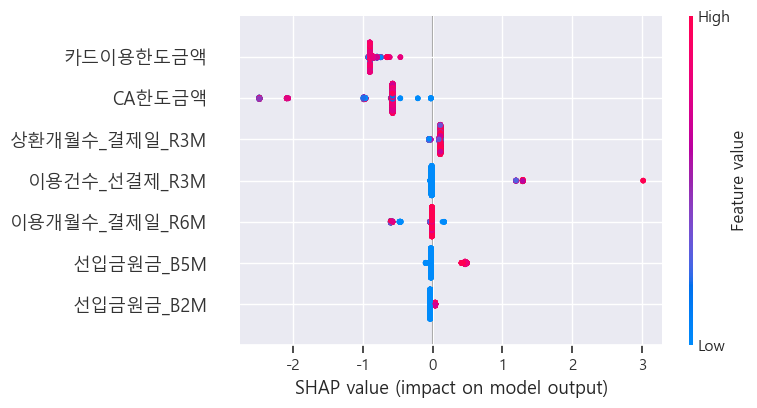

         feature  importance
0       카드이용한도금액    0.420905
1         CA한도금액    0.339192
6  이용개월수_결제일_R6M    0.075471
3      선입금원금_B2M    0.072830
2   이용건수_선결제_R3M    0.063808
5      선입금원금_B5M    0.019922
4  상환개월수_결제일_R3M    0.007872


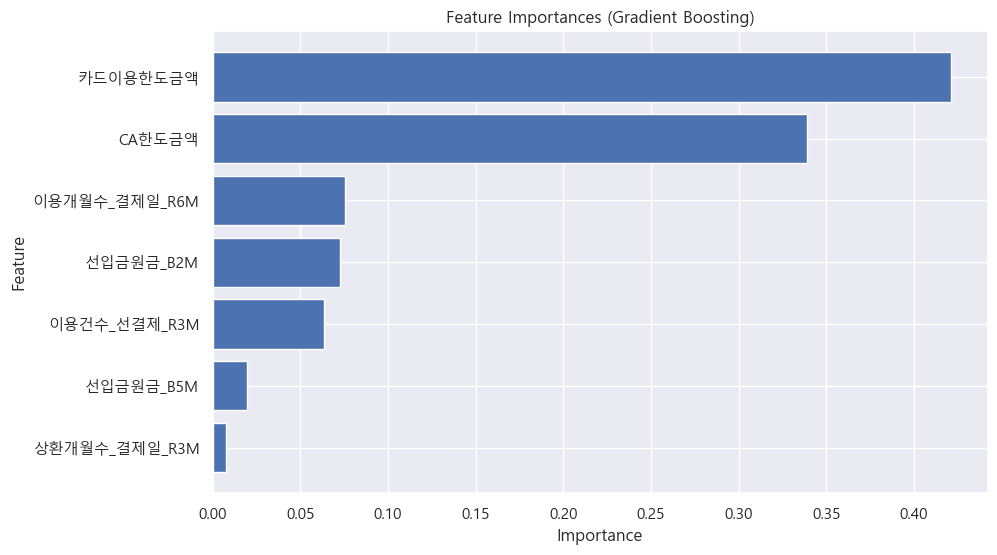

In [92]:
# 최종 모델 지정 (GridSearchCV 사용한 경우)
final_model = grid_clf2.best_estimator_

# SHAP용 TreeExplainer 생성
explainer = shap.Explainer(final_model)  # sklearn 모델은 이렇게 생성

# 원래 데이터에서 샘플링 (해석력 보존)
X_df_original = pd.DataFrame(X, columns=df1.drop('Segment', axis=1).columns)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

# SHAP 값 계산 및 시각화
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample)
plt.show()

# ✅ 중요도 추출 (GradientBoostingClassifier는 feature_importances_ 사용)
importances = final_model.feature_importances_

# 컬럼 이름 가져오기
feature_names = df1.drop('Segment', axis=1).columns.tolist()

# DataFrame 생성 및 정렬
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 출력
print(importance_df.head(7))

# 막대 그래프 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### XG부스트 피처중요도 확인

In [82]:
# 최종 모델 지정
final_model = grid_clf4.best_estimator_

# TreeExplainer 객체 생성
explainer = shap.TreeExplainer(final_model)

# 검증 데이터에서 3만 개 샘플링 (test_X는 이미 표준화된 형태)
# → 원래 X에서 샘플링하는 게 더 해석력 높음 (스케일 전)
X_df_original = pd.DataFrame(X, columns=df1.drop('Segment', axis=1).columns)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

# 샘플 데이터에 대한 SHAP 값 계산
shap_values = explainer.shap_values(X_sample)

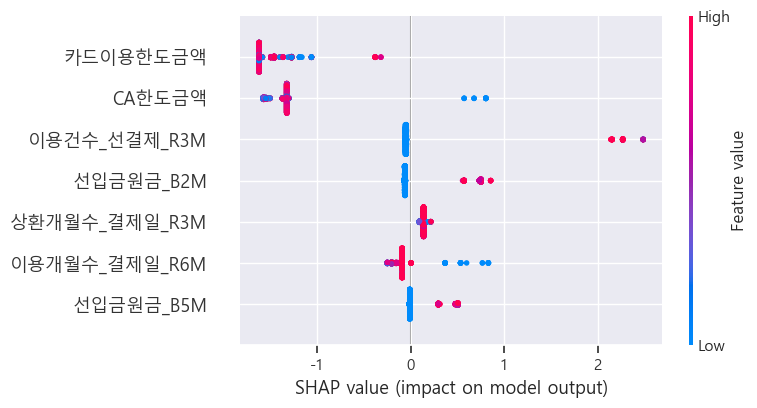

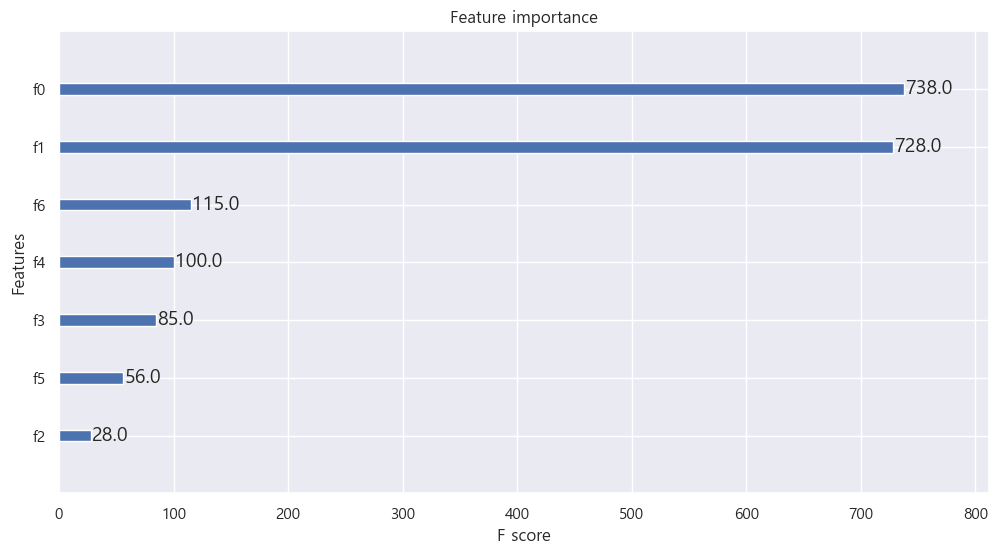

In [84]:
# SHAP 요약 플롯 그리기
shap.summary_plot(shap_values, X_sample)
plt.show()

# 중요도 시각화 (XGBoost 내장)
xgb.plot_importance(final_model)
plt.show()

In [76]:
# 3가지 지원하지만 그중 'gain'이 가장 의미 있는 기준
# gain은 예측 성능에 가장 크게 기여한 피처 파악 가능함, 해당 피처를 사용해 얻은 정보 이득의 평균

# 중요도 딕셔너리 추출
importance_dict = final_model.get_booster().get_score(importance_type='gain')

# DataFrame 먼저 생성
importance_df = pd.DataFrame(importance_dict.items(), columns=['feature', 'importance'])

# 컬럼 이름 리스트 만들기
feature_names = df1.drop('Segment', axis=1).columns.tolist()

# f0 → 실제 컬럼명으로 매핑
mapping = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_df['feature'] = importance_df['feature'].map(mapping)

# 중요도 기준 정렬
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 결과 출력
print(importance_df.head(7))

         feature  importance
2   이용건수_선결제_R3M    4.208557
6  이용개월수_결제일_R6M    2.270796
1         CA한도금액    1.758904
0       카드이용한도금액    1.354626
3      선입금원금_B2M    1.226646
4  상환개월수_결제일_R3M    0.805506
5      선입금원금_B5M    0.618609


### 학습한 데이터를 통해 검증을 한다

In [56]:
#검증용 데이터에 대한 평가 수치를 확인한다.
pred_y1 = grid_clf.best_estimator_.predict(test_X)
pred_y2 = grid_clf2.best_estimator_.predict(test_X)
pred_y3 = grid_clf3.best_estimator_.predict(test_X)
pred_y4 = grid_clf4.best_estimator_.predict(test_X)

f1_point1 = f1_score(test_y, pred_y1)
f1_point2 = f1_score(test_y, pred_y2)
f1_point3 = f1_score(test_y, pred_y3)
f1_point4 = f1_score(test_y, pred_y4)

display(f1_point1)
display(f1_point2)
display(f1_point3)
display(f1_point4)

0.7391304347826089

0.8333333333333333

0.816326530612245

0.7843137254901961

In [45]:
#XGBoost
# 혼동 행렬 및 지표 저장
cm = confusion_matrix(test_y, pred_y4)
precision = precision_score(test_y, pred_y4, zero_division=0)
recall = recall_score(test_y, pred_y4, zero_division=0)
f1 = f1_score(test_y, pred_y4, zero_division=0)


print("Classification Report:")
print(classification_report(test_y, pred_y4, zero_division=0))
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       199
           1       0.77      0.80      0.78        25

    accuracy                           0.95       224
   macro avg       0.87      0.88      0.88       224
weighted avg       0.95      0.95      0.95       224

Confusion Matrix:
 [[193   6]
 [  5  20]]
Precision: 0.7692307692307693
Recall: 0.8
F1 Score: 0.7843137254901961


In [58]:
#GradientBoosting
# 혼동 행렬 및 지표 저장
cm = confusion_matrix(test_y, pred_y2)
precision = precision_score(test_y, pred_y2, zero_division=0)
recall = recall_score(test_y, pred_y2, zero_division=0)
f1 = f1_score(test_y, pred_y2, zero_division=0)


print("Classification Report:")
print(classification_report(test_y, pred_y2, zero_division=0))
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.87      0.80      0.83        25

    accuracy                           0.96       224
   macro avg       0.92      0.89      0.91       224
weighted avg       0.96      0.96      0.96       224

Confusion Matrix:
 [[196   3]
 [  5  20]]
Precision: 0.8695652173913043
Recall: 0.8
F1 Score: 0.8333333333333333


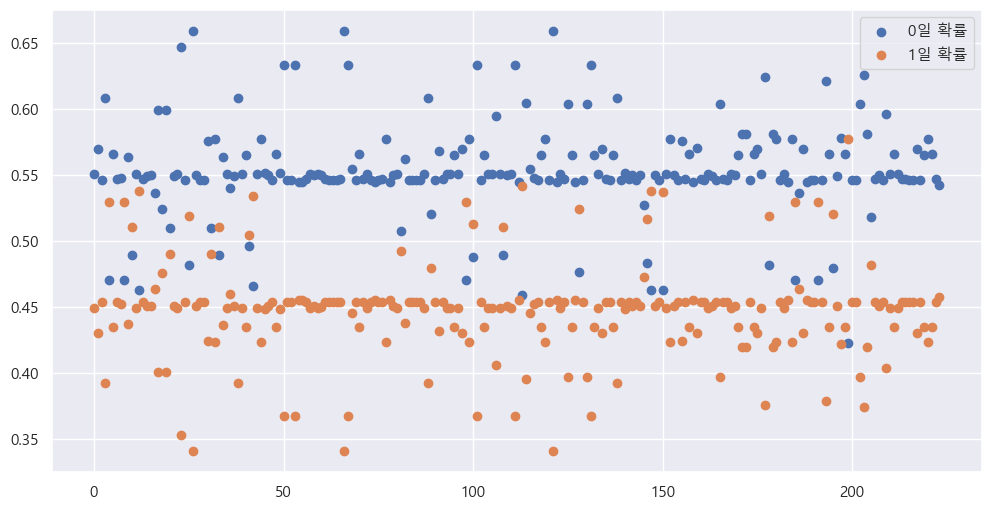

In [60]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf.best_estimator_.predict_proba(test_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

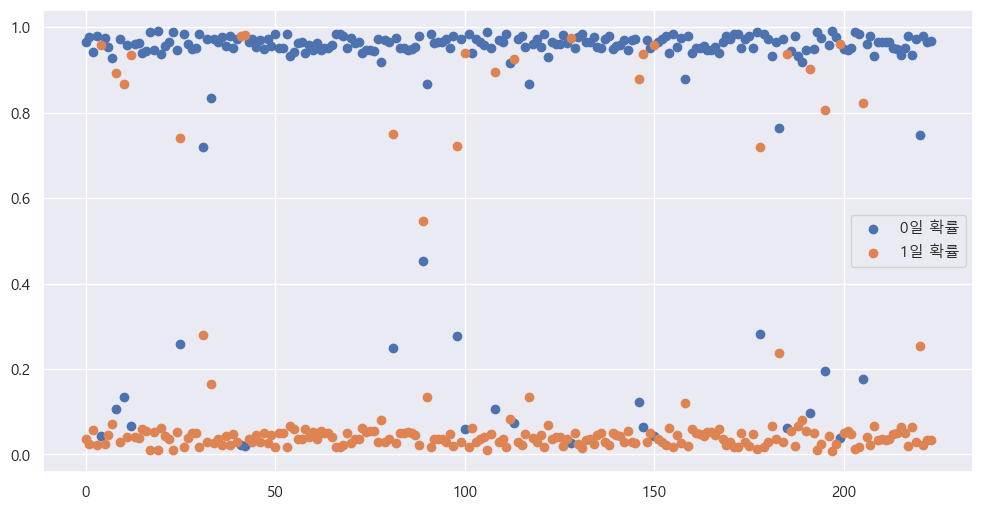

In [62]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf2.best_estimator_.predict_proba(test_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

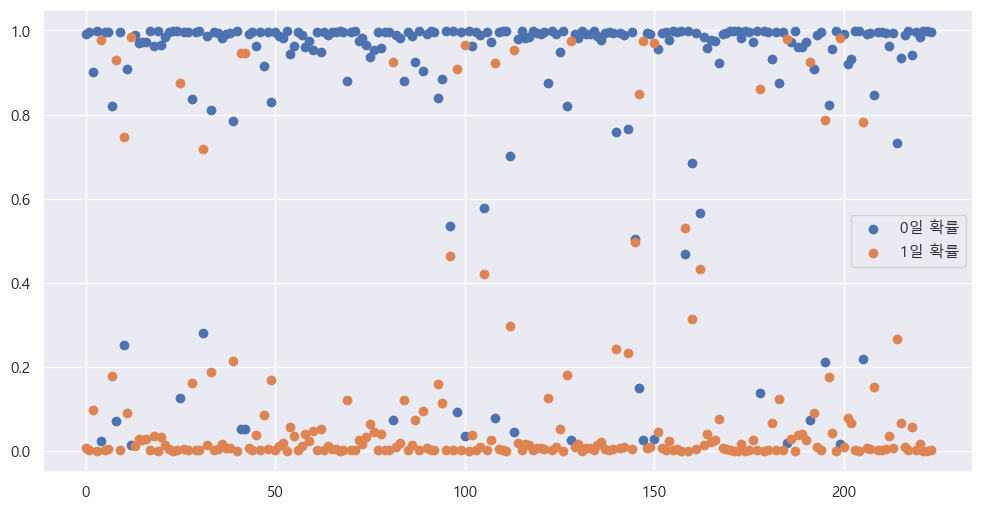

In [64]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf3.best_estimator_.predict_proba(test_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

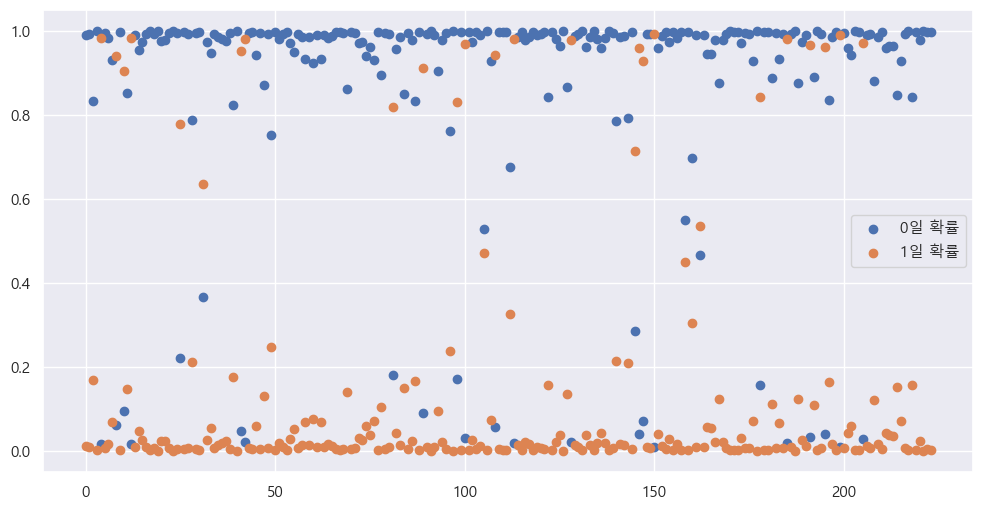

In [66]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf4.best_estimator_.predict_proba(test_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

### 예측을 수행한다

In [16]:
# 예측할 데이터를 읽어온다.
df2 = pd.read_csv('data/breast_cancer_new.csv')
# 입력 데이터에 대한 표준화
scaled_data = scaler1.transform(df2)
scaled_data

array([[-0.46250369, -0.45164581, -0.50218195, ..., -0.28043066,
         0.5116929 , -0.5831113 ],
       [-0.24537993,  2.87283471, -0.26498762, ..., -0.59279929,
        -1.15425761, -0.39577673],
       [-0.74533596,  2.52250257, -0.7406203 , ..., -0.7316298 ,
        -0.08705654, -0.64284116],
       ...,
       [ 0.67453917,  2.22606768,  0.64563954, ...,  0.3671957 ,
        -1.12013199, -0.31704191],
       [ 1.81729582,  2.53230207,  1.96430728, ...,  2.21029035,
         1.77899418,  2.16989242],
       [-1.85095302,  1.3588119 , -1.85817047, ..., -1.75415837,
        -0.10722167, -0.74112394]])

In [17]:
# 결과를 예측한다.
y_pred1 = grid_clf.best_estimator_.predict(scaled_data)
y_pred2 = grid_clf2.best_estimator_.predict(scaled_data)
y_pred3 = grid_clf3.best_estimator_.predict(scaled_data)
y_pred4 = grid_clf4.best_estimator_.predict(scaled_data)

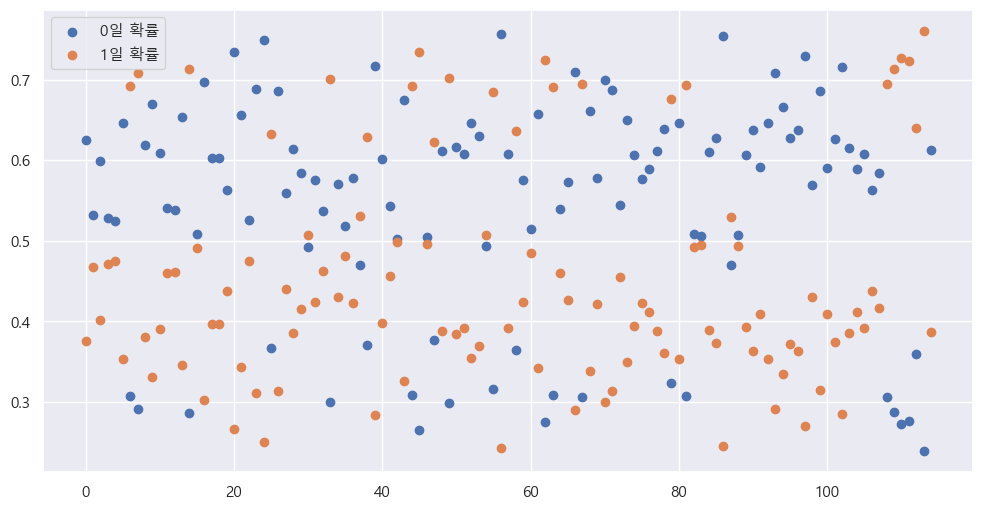

In [18]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf.best_estimator_.predict_proba(scaled_data)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

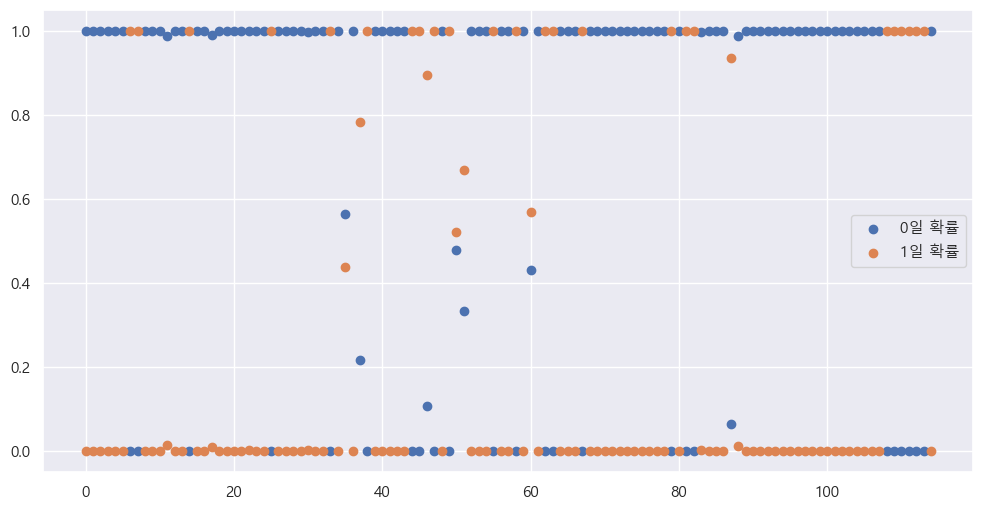

In [20]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf2.best_estimator_.predict_proba(scaled_data)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

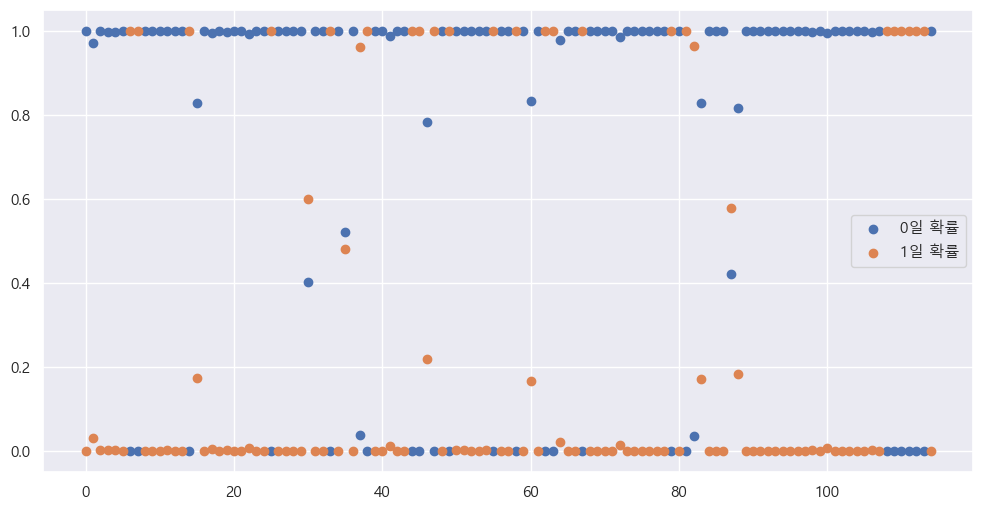

In [21]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf3.best_estimator_.predict_proba(scaled_data)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

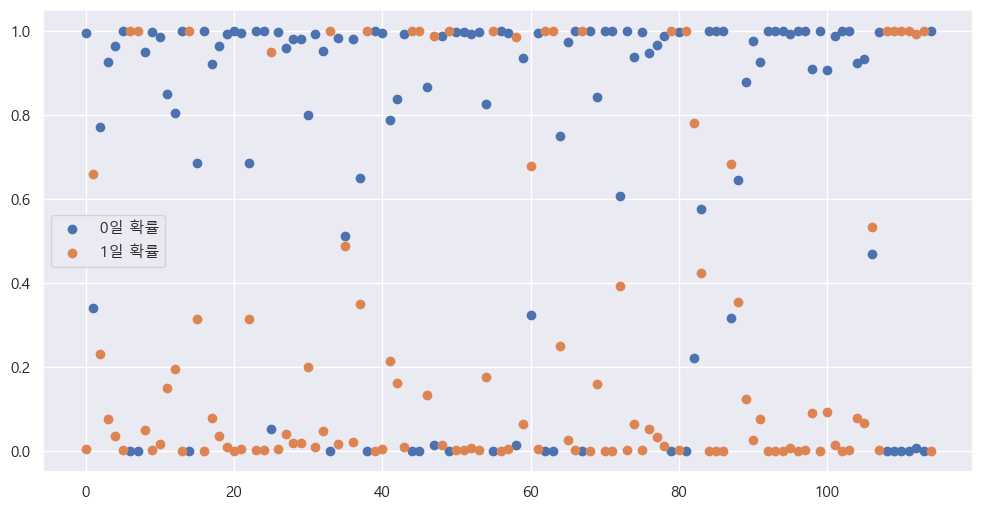

In [22]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = grid_clf4.best_estimator_.predict_proba(scaled_data)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.legend()
plt.show()

In [23]:
# 결과 데이터를 복원한다.
result_data1 = encoder1.inverse_transform(y_pred1)
result_data2 = encoder1.inverse_transform(y_pred2)
result_data3 = encoder1.inverse_transform(y_pred3)
result_data4 = encoder1.inverse_transform(y_pred4)

In [24]:
# 결과를 저장한다.
df2['target'] = result_data1
df2.to_csv('data/breast_cancer_AdaBoost.csv', index=False)

df2['target'] = result_data2
df2.to_csv('data/breast_cancer_GradientBoost.csv', index=False)

df2['target'] = result_data3
df2.to_csv('data/breast_cancer_LGBMBoost.csv', index=False)

df2['target'] = result_data4
df2.to_csv('data/breast_cancer_XGBoost.csv', index=False)

print('저장완료')

저장완료


### 회귀

In [25]:
# 데이터를 불러온다.
df1 = pd.read_csv('data/boston.csv')
# 입력과 결과로 나눈다.
X = df1.drop('target', axis=1)
y = df1['target']
# 전처리
scaler1 = StandardScaler()
scaler1.fit(X)
X2 = scaler1.transform(X)
# 학습용과 검증용으로 데이터를 나눈다.
train_X, test_X, train_y, test_y = train_test_split(X2, y, test_size=0.2, random_state=1)

### 기본 모델 사용

In [26]:
model1 = AdaBoostRegressor()
model2 = GradientBoostingRegressor()
model3 = LGBMRegressor()
model4 = XGBRegressor()
# 교차 검증 수행
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

r1 = cross_val_score(model1, train_X, train_y, scoring='neg_mean_squared_error', cv=kfold)
r2 = cross_val_score(model2, train_X, train_y, scoring='neg_mean_squared_error', cv=kfold)
r3 = cross_val_score(model3, train_X, train_y, scoring='neg_mean_squared_error', cv=kfold)
r4 = cross_val_score(model4, train_X, train_y, scoring='neg_mean_squared_error', cv=kfold)

print(f'평균 mse 수치 : {abs(r1).mean()}')
print(f'평균 mse 수치 : {abs(r2).mean()}')
print(f'평균 mse 수치 : {abs(r3).mean()}')
print(f'평균 mse 수치 : {abs(r4).mean()}')

평균 mse 수치 : 9.567378302559394
평균 mse 수치 : 7.183661038332753
평균 mse 수치 : 7.6774153541961905
평균 mse 수치 : 9.458539210389782


### 모델 하이퍼 파라미터 튜닝

In [28]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model1 = AdaBoostRegressor()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf1 = GridSearchCV(model1, param_grid=params, scoring='neg_mean_squared_error', cv=kfold)
grid_clf1.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf1.best_params_}')
print(f'최적의 모델 평균 성능 : {abs(grid_clf1.best_score_)}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.0001, 'n_estimators': 50}
최적의 모델 평균 성능 : 10.790535678347785


In [29]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model2 = GradientBoostingRegressor()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf2 = GridSearchCV(model2, param_grid=params, scoring='neg_mean_squared_error', cv=kfold)
grid_clf2.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf2.best_params_}')
print(f'최적의 모델 평균 성능 : {abs(grid_clf2.best_score_)}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.0001, 'n_estimators': 50}
최적의 모델 평균 성능 : 80.1648648660103


In [30]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model3 = LGBMRegressor()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf3 = GridSearchCV(model3, param_grid=params, scoring='neg_mean_squared_error', cv=kfold)
grid_clf3.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf3.best_params_}')
print(f'최적의 모델 평균 성능 : {abs(grid_clf3.best_score_)}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.0001, 'n_estimators': 50}
최적의 모델 평균 성능 : 80.1632976328106


In [31]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model4 = XGBRegressor()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf4 = GridSearchCV(model4, param_grid=params, scoring='neg_mean_squared_error', cv=kfold)
grid_clf4.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf4.best_params_}')
print(f'최적의 모델 평균 성능 : {abs(grid_clf4.best_score_)}')

최적의 하이퍼 파라미터 : {'booster': 'gblinear', 'learning_rate': 0.0001, 'n_estimators': 50}
최적의 모델 평균 성능 : 79.16657425314158


### 학습 데이터를 가지고 평가

In [32]:
y_pred1 = grid_clf1.best_estimator_.predict(train_X)
y_pred2 = grid_clf2.best_estimator_.predict(train_X)
y_pred3 = grid_clf3.best_estimator_.predict(train_X)
y_pred4 = grid_clf4.best_estimator_.predict(train_X)

In [33]:
# 진짜 결과와 예측 결과의 mse 수치를 확인한다.
r1 = mean_squared_error(train_y, y_pred1)
r2 = mean_squared_error(train_y, y_pred2)
r3 = mean_squared_error(train_y, y_pred3)
r4 = mean_squared_error(train_y, y_pred4)

display(r1)
display(r2)
display(r3)
display(r4)

6.7651632568683695

79.44701820509015

79.44536549232012

78.43794013088355

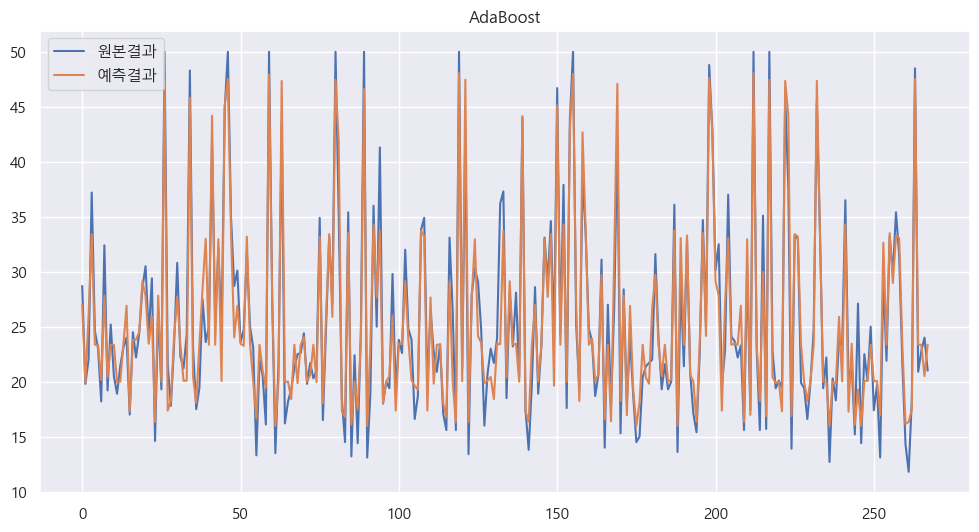

In [34]:
# 데이터 패턴을 비교한다.
plt.plot(train_y.values, label='원본결과')
plt.plot(y_pred1, label='예측결과')
plt.title('AdaBoost')
plt.legend()
plt.show()

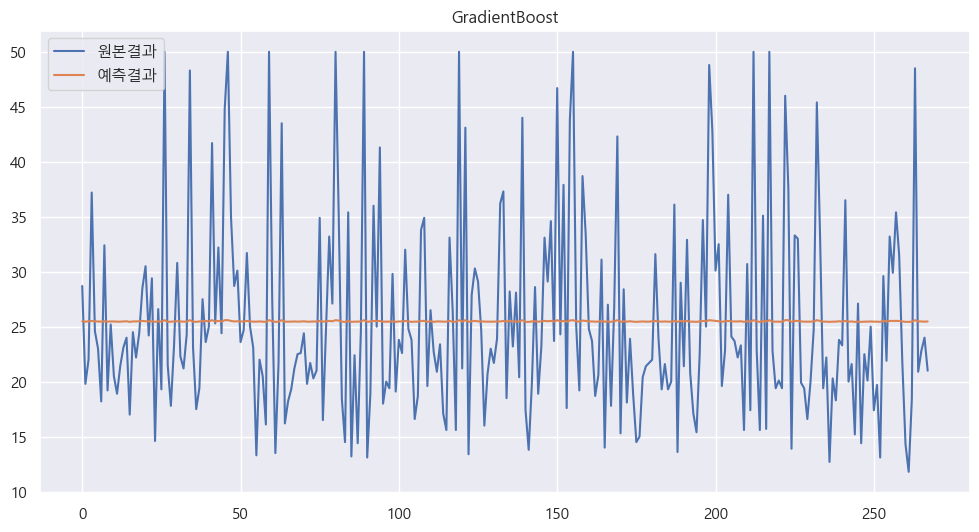

In [35]:
# 데이터 패턴을 비교한다.
plt.plot(train_y.values, label='원본결과')
plt.plot(y_pred2, label='예측결과')
plt.title('GradientBoost')
plt.legend()
plt.show()

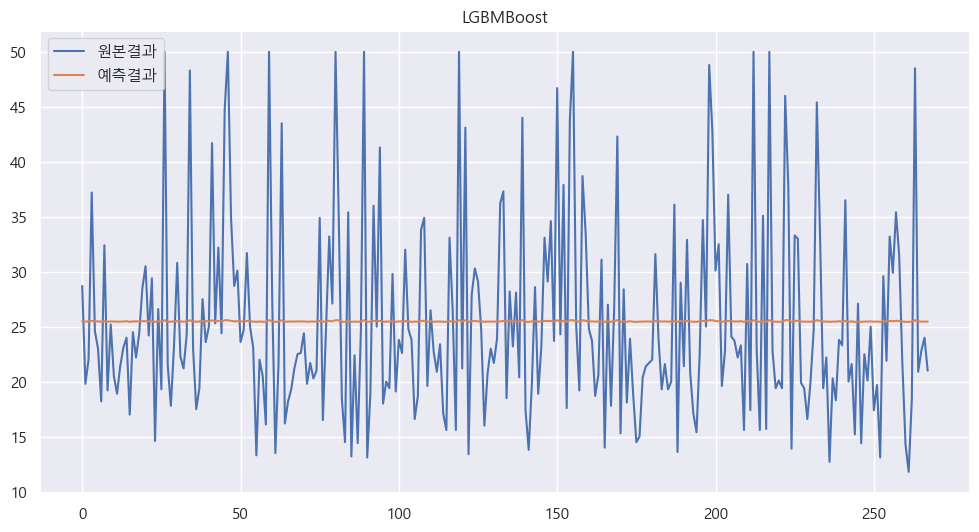

In [36]:
# 데이터 패턴을 비교한다.
plt.plot(train_y.values, label='원본결과')
plt.plot(y_pred3, label='예측결과')
plt.title('LGBMBoost')
plt.legend()
plt.show()

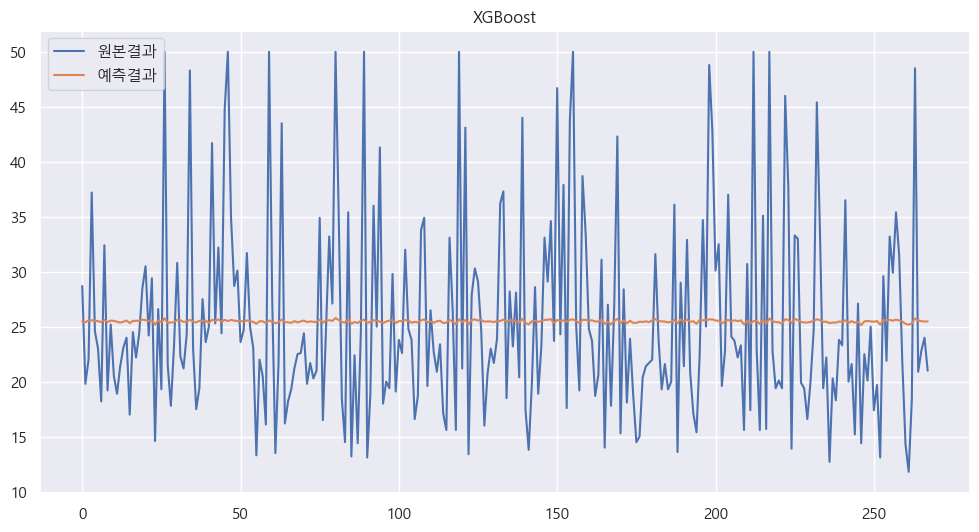

In [37]:
# 데이터 패턴을 비교한다.
plt.plot(train_y.values, label='원본결과')
plt.plot(y_pred4, label='예측결과')
plt.title('XGBoost')
plt.legend()
plt.show()